In [597]:
import numpy as np
import csv
from scipy import signal
import matplotlib.pyplot as plt

(1000,)


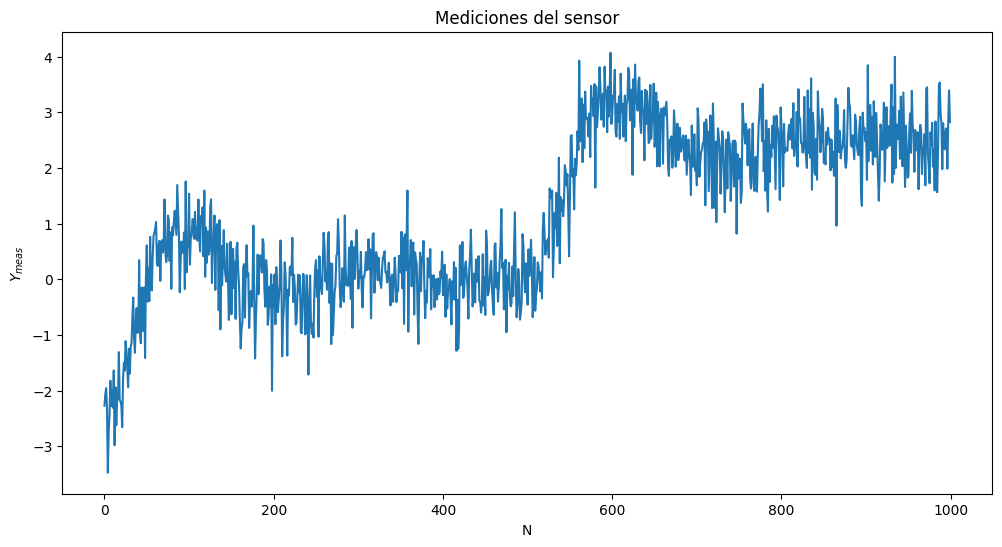

In [598]:
def cargar_dataset(nombre_archivo):
    dataset = []
    with open(nombre_archivo, newline='') as csvfile:
      reader = csv.reader(csvfile)
      for row in reader:
        dataset.append(row[0])
    dataset = np.array(dataset)
    dataset = dataset[:].astype(float)
    return dataset

Ymeas = cargar_dataset("Ymeas.txt")
N = len(Ymeas)
#salida -= np.mean(salida)
print(Ymeas.shape)

plt.figure(figsize=(12,6))
plt.title("Mediciones del sensor")
plt.xlabel("N")
plt.ylabel("$Y_{{meas}}$")
plt.plot(Ymeas)
plt.show()

Acá se nos abren 2 interpretaciones para ese "y2 ideal".

1) y2 son los datos que hemos ido obteniendo hasta ahora (ventana móvil). Acá laburaríamos con el modelo del sistema ya que conocemos A, B y C.
2) y2 son las mediciones de un sensor bueno (un buen velocímetro, por ejemplo).

CASO 1

In [599]:
b = 4.0  # Damping constant
k = 2.0  # Stiffness of the spring
m = 20.0  # Mass
# F = 5.0  # Force
Ac = np.array([[0.0, 1.0], [-k / m, -b / m]])
Bc = np.array([[0.0], [1.0 / m]])
Cc = np.array([[1.0, 0.0]])
Dc = 0

Cc_sec = np.array([[0.0, 1.0]])

dt = 0.1  # seconds      

#x0 = np.array([0.0, 0.0])
x0 = np.array([-2.5, 0.25])
(Ad, Bd, Cd, Dd, _) = signal.cont2discrete((Ac, Bc, Cc, Dc), dt, method='zoh', alpha=None)
(Ad_sec, Bd_sec, Cd_sec, Dd_sec, _) = signal.cont2discrete((Ac, Bc, Cc_sec, Dc), dt, method='zoh', alpha=None)

print(Ad, Bd, Cd, Dd)
print(Ad_sec, Bd_sec, Cd_sec, Dd_sec)

Nsim = 1000

Nx = 2
Ny = 1
Nu = 1

Xsim = np.zeros((Nsim+1, Nx))
Ysim = np.zeros((Nsim, Ny))
Ysim_sec = np.zeros((Nsim, Ny))
Ymeas = np.zeros((Nsim, Ny))
Ymeas_sec = np.zeros((Nsim, Ny))
Usim = np.ones((Nsim, Nu)) * 0.0
Usim[500:] = 5.0

Xsim[0, :] = x0

for k in range(Nsim):
    Xsim[k+1, :] = Ad @ Xsim[k, :] + Bd @ Usim[k, :]
    Ysim[k, :] = Cd @ Xsim[k, :]
    Ysim_sec[k, :] = Cd_sec @ Xsim[k, :]

    Ymeas[k, :] = Ysim[k, :] + np.random.randn(Ny) * 0.5
    Ymeas_sec[k, :] = Ysim_sec[k, :] + np.random.randn(Ny) * 0.25

[[ 0.99950336  0.09899013]
 [-0.00989901  0.97970533]] [[0.00024832]
 [0.00494951]] [[1. 0.]] 0
[[ 0.99950336  0.09899013]
 [-0.00989901  0.97970533]] [[0.00024832]
 [0.00494951]] [[0. 1.]] 0


In [600]:
# La idea es ubicarnos en cada instancia de Ymeas
# e ir corrigiendo la estimación de x_k (obtenida con Ymeas)
# con el x_k obtenido de simular el sistema en la ventana móvil
# seleccionada.

ventana_movil = 2 # Usamos los 2 datos anteriores.
w1 = np.array([[1]])
X_est = []

K = np.array([[0.1],
              [0.05]])

for k in range(Nsim):
    y_meas = Ymeas[k]
    # Estimacion inicial de x_ con lo medido (no definitiva)
    # No usamos la expresion con matrices pq no podemos obtener
    # la velocidad, al no ser observable.
    if k == 0:
        x_k = np.array([y_meas[0], 0.0])
    else:
        x_k = np.array([y_meas[0], X_est[-1][1]])
    
    X_est.append(x_k)

    y_model = np.zeros_like(y_meas)

    x_k_model = None
    y_k_model = None
    for i in range(ventana_movil-1, -1, -1):
        # Evitamos indices negativos
        if k-i >= 0:
            if x_k_model is None:
                # Comenzamos el modelo al inicio de la ventana móvil
                # El valor de x_k allí será el estimado para ese punto.
                x_k_model = X_est[k-i]

            x_k_model = Ad @ x_k_model + Bd @ Usim[k-i]
            y_k_model = Cd @ x_k_model
            
            # De esta forma simulamos la evolución del sistema
            # en la ventana móvil.
    # Tras finalizar, x_k_model debería tener el x_k siguiendo el modelo
    # hasta el instante k, habiendo comenzado en k-ventana_móvil.

    # H1 = H2 = Cd en este caso
    """
    No podemos usar esto por lo explicado arriba (matriz singular)
    term1 = 0.5 * np.linalg.inv(Cd.T @ w1 @ Cd)
    term2 = np.linalg.inv(Cd.T @ w1 @ Cd)
    term3 = Cd @ np.linalg.inv(0.5*Cd.T @ term2 @ Cd)
    K = term1 @ term3
    """
    # Entonces usaremos las pseudo-inversas.
    # Esto revienta, asi que usaremos una K controlada xd.
    """
    term1 = 0.5 * np.linalg.pinv(Cd.T @ w1 @ Cd)
    term2 = np.linalg.pinv(Cd.T @ w1 @ Cd)
    term3 = np.linalg.pinv(0.5 * Cd @ term2 @ Cd.T)
    K = term1 @ Cd.T @ term3
    """

    # ¿Le creemos más a la medición? y_meas - y_k_model
    # ¿Le creemos más al modelo? y_k_model - y_meas
    error = y_meas - y_k_model
    x_corregido = x_k_model + K @ error
    
    #x_corregido = x_k + K @ (y_k_model - y_meas)
    X_est[-1] = x_corregido


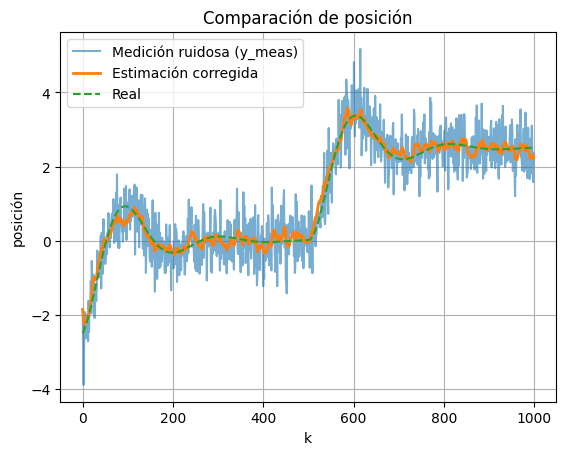

In [601]:
X_est = np.array(X_est)

plt.figure()
plt.plot(Ymeas, label="Medición ruidosa (y_meas)", alpha=0.6)
plt.plot(X_est[:,0], label="Estimación corregida", linewidth=2)
plt.plot(Xsim[:-1,0], label="Real", linestyle="--")

plt.legend()
plt.title("Comparación de posición")
plt.xlabel("k")
plt.ylabel("posición")
plt.grid()

CASO 2

In [ ]:
# La idea es ubicarnos en cada instancia de Ymeas
# e ir corrigiendo la estimación de x_k (obtenida con Ymeas)
# con el x_k del sensor bueno (Ymeas_sec)

w1 = np.array([[1]])
X_est = []

K = np.array([[0.05],
              [0.01]])
print(Ymeas.shape, Ymeas_sec.shape)

for k in range(Nsim):
    y_meas = Ymeas[k]
    y_meas_sec = Ymeas_sec[k]
    # Estimacion inicial de x_ con lo medido (no definitiva)
    # Como ahora tenemos acceso a la posición (mala calidad)
    # y a la velocidad (buena calidad), mejoramos dicha 
    # estimación x_ con lo medido por el sensor bueno
    
    if k == 0:
        x_k = np.array([y_meas[0], y_meas_sec[0]])
    else:
        # Suponemos que no tenemos modelo, así que estipulamos
        # como un nuevo modelito simple que x_k = x_k-1 + dt * v_k-1
        # Este es un esquema clásico de movimiento lineal en la dirección
        # de la velocidad.
        pos_pred = X_est[-1][0] + dt * y_meas_sec[0]
        
        # Ahora hacemos una combinación lineal entre la posición actual
        # sensada y la predicha por nuestro modelo (aprovechando la
        # información brindada por el sensor bueno).

        alpha = 0.9 # Cuánto confiamos en el sensor bueno
        pos_final = alpha * pos_pred + (1 - alpha) * y_meas[0]

        x_k = np.array([pos_final, y_meas_sec[0]])

    X_est.append(x_k)

(1000, 1) (1000, 1)


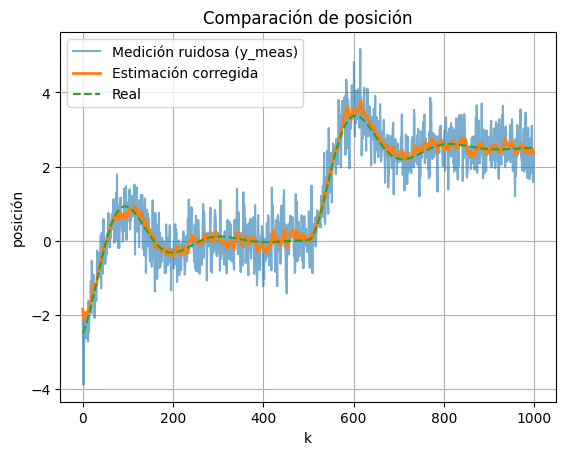

In [603]:
X_est = np.array(X_est)

plt.figure()
plt.plot(Ymeas, label="Medición ruidosa (y_meas)", alpha=0.6)
plt.plot(X_est[:,0], label="Estimación corregida", linewidth=2)
plt.plot(Xsim[:-1,0], label="Real", linestyle="--")

plt.legend()
plt.title("Comparación de posición")
plt.xlabel("k")
plt.ylabel("posición")
plt.grid()